# Librerías

In [1]:
import scienceplots
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ccdproc

from astropy.io import fits
from astropy import units as u
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.nddata import CCDData, Cutout2D
from astropy.table import Table, QTable
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
from astropy.visualization import (MinMaxInterval, SqrtStretch, LogStretch, LinearStretch, ImageNormalize, ZScaleInterval)
from matplotlib.colors import LogNorm

from os import listdir  
from os.path import join
from ccdproc import subtract_bias ,subtract_dark, flat_correct, combine
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, ApertureStats
from photutils.background import Background2D, MedianBackground
from astroquery.astrometry_net import AstrometryNet
from sklearn.mixture import GaussianMixture

plt.style.use('science')
%matplotlib inline

import warnings
from astropy.utils.exceptions import AstropyWarning
from astropy import log
warnings.simplefilter('ignore', category=AstropyWarning)
log.setLevel('ERROR')

# Funciones

In [2]:
def get_clean_band(df, band='g'):
    """band: 'g', 'bp', o 'rp'"""
    time_col = f"{band}_transit_time" if band == 'g' else f"{band}_obs_time"
    mag_col = f"{band}_transit_mag" if band == 'g' else f"{band}_mag"
    reject_col = f"variability_flag_{band}_reject"
    
    mask = (~df['rejected_by_photometry'].astype(bool)) & (~df[reject_col].astype(bool)) & df[mag_col].notna()
    
    return df.loc[mask, time_col].values, df.loc[mask, mag_col].values

def count_good_points(sid):
    df = lightcurves.get(sid)
    if df is None:
        return 0
    time, mag = get_clean_band(df, band='g')
    return len(time)

# Posición central de imagen coadd

In [3]:
with fits.open("fits/image_deep_coadd-g.fits") as hdul:
    header = hdul[1].header
    wcs = WCS(header)
    ny, nx = hdul[1].data.shape

x_centro = nx / 2
y_centro = ny / 2

centro = wcs.pixel_to_world(x_centro, y_centro)
print(f"RA  = {centro.ra.deg:.6f} deg")
print(f"Dec = {centro.dec.deg:.6f} deg")
print(centro.to_string('hmsdms'))

RA  = 4.885825 deg
Dec = -72.065185 deg
00h19m32.59792761s -72d03m54.66424412s


# Diagrama g-r

In [4]:
tabla = Table.read("fits/data.csv", format="csv")

es_estrella = tabla['refExtendedness'] == 0
tabla_estrellas = tabla[es_estrella]

mag_g = np.array(tabla_estrellas['g_psfMag'])
mag_r = np.array(tabla_estrellas['r_psfMag'])
color = mag_g - mag_r

mask_valida = np.isfinite(color) & np.isfinite(mag_g) & (mag_g != 0) & (mag_r != 0)
print(f"Estrellas con fotometría válida: {np.sum(mask_valida)} de {len(tabla_estrellas)}")

Estrellas con fotometría válida: 25041 de 50488


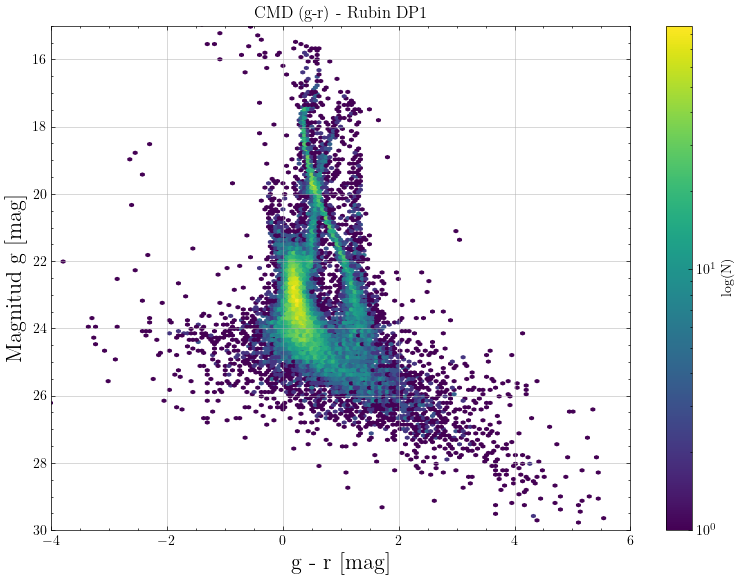

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(color[mask_valida], mag_g[mask_valida], gridsize=250, bins='log', cmap='viridis', mincnt=1)

ax.set_xlabel("g - r [mag]", fontsize=16)
ax.set_ylabel("Magnitud g [mag]", fontsize=16)
ax.set_title("CMD (g-r) - Rubin DP1")
ax.grid(True, alpha=0.7)
ax.set_xlim(-4, 6)
ax.set_ylim(15, 30)
ax.invert_yaxis()

plt.colorbar(hb, label="log(N)")
plt.tight_layout()
plt.savefig('image/2 - CMD Rubin.pdf')
plt.show()

# rubin

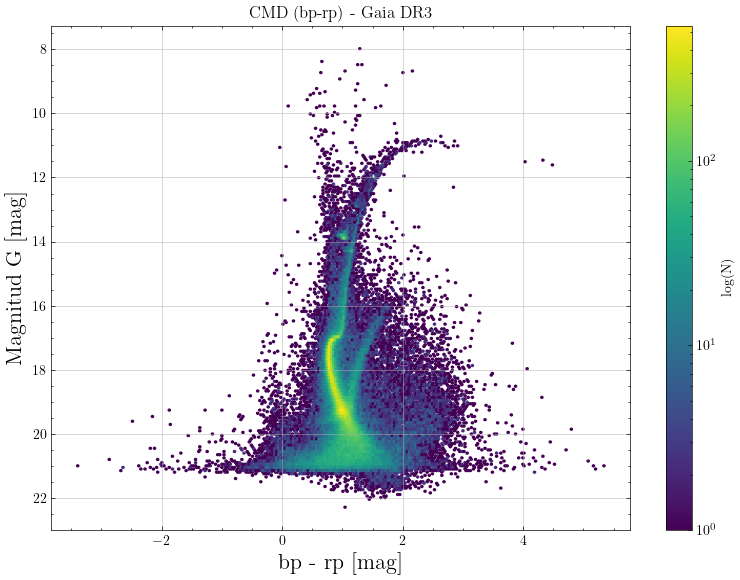

In [6]:
tabla_gaia = Table.read('fits/data.fits', format='fits')
tabla_gaia.colnames

fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(tabla_gaia['bp_rp'], tabla_gaia['phot_g_mean_mag'], gridsize=250, bins='log', cmap='viridis', mincnt=1)
ax.invert_yaxis()
ax.set_xlabel("bp - rp [mag]", fontsize=16)
ax.set_ylabel("Magnitud G [mag]", fontsize=16)
ax.set_title("CMD (bp-rp) - Gaia DR3")
ax.grid(True, alpha=0.7)

plt.colorbar(hb, label="log(N)")
plt.tight_layout()
plt.savefig('image/2 - CMD Gaia.pdf')
plt.show()

# gaia

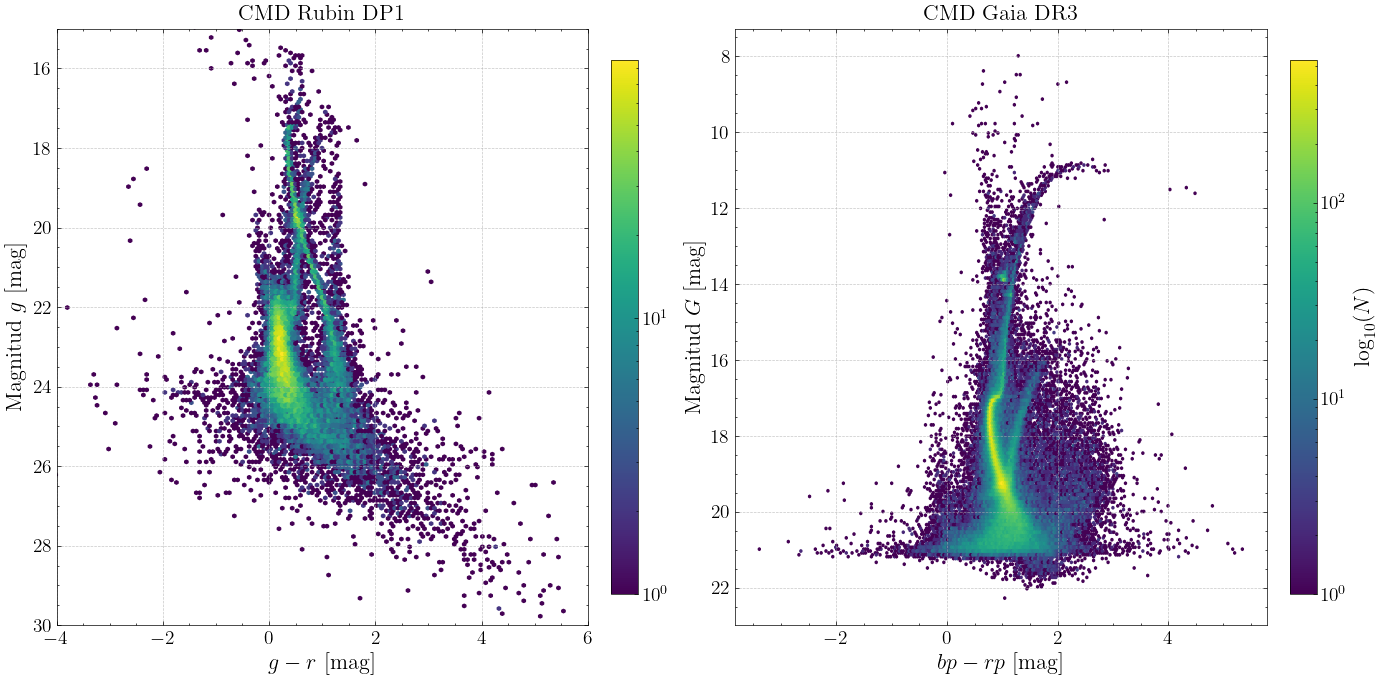

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

# Panel 1: Rubin DP1
hb1 = ax1.hexbin(
    color[mask_valida],
    mag_g[mask_valida],
    gridsize=250,
    bins='log',
    cmap='viridis',
    mincnt=1
)
ax1.invert_yaxis()
ax1.set_xlabel(r"$g - r$ [mag]", fontsize=16)
ax1.set_ylabel(r"Magnitud $g$ [mag]", fontsize=16)
ax1.set_title("CMD Rubin DP1", fontsize=16)
ax1.set_xlim(-4, 6)
ax1.set_ylim(30, 15)
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.tick_params(labelsize=14)

cb1 = fig.colorbar(hb1, ax=ax1, fraction=0.046, pad=0.04)
cb1.ax.tick_params(labelsize=14)

# Panel 2: Gaia DR3
hb2 = ax2.hexbin(
    tabla_gaia['bp_rp'],
    tabla_gaia['phot_g_mean_mag'],
    gridsize=250,
    bins='log',
    cmap='viridis',
    mincnt=1
)
ax2.invert_yaxis()
ax2.set_xlabel(r"$bp-rp$ [mag]", fontsize=16)
ax2.set_ylabel(r"Magnitud $G$ [mag]", fontsize=16)
ax2.set_title("CMD Gaia DR3", fontsize=16)
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.tick_params(labelsize=14)

cb2 = fig.colorbar(hb2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label(r"$\log_{10}(N)$", fontsize=16)
cb2.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('image/2 - CMD Rubin vs Gaia.pdf', bbox_inches='tight')
plt.show()

# Segregación poblacional por PM

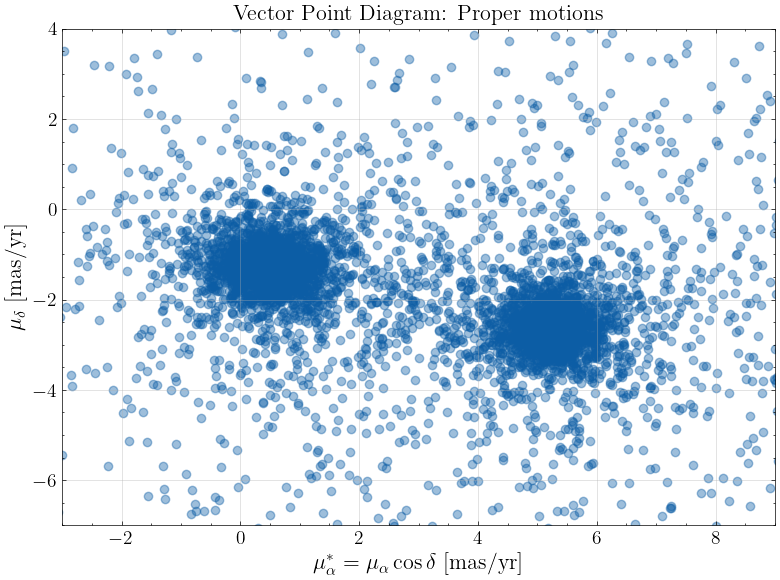

In [8]:
tabla_rg = Table.read('fits/rubin_gaia.fits', format='fits')
df = tabla_rg.to_pandas()
t = df.dropna(subset=['pmra', 'pmdec']).reset_index(drop=True)

mask_pm = np.isfinite(t["pmra"]) & np.isfinite(t["pmdec"])
pmra = t["pmra"][mask_pm]
pmdec = t["pmdec"][mask_pm]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pmra, pmdec, alpha=0.4)

ax.set_xlabel(r"$\mu_{\alpha}^* = \mu_{\alpha} \cos \delta$ [mas/yr]", fontsize=16)
ax.set_ylabel(r"$\mu_{\delta}$ [mas/yr]", fontsize=16)
ax.set_title("Vector Point Diagram: Proper motions", fontsize=16)

ax.set_xlim(-3, 9)
ax.set_ylim(-7, 4)
ax.grid(alpha=0.5)
ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('image/3 - Vector Point Diagram.pdf')
plt.show()

In [9]:
X = np.column_stack((t['pmra'], t['pmdec']))

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)
for i in range(3):
    print(f"Componente {i} -> Centroide: pmra = {gmm.means_[i, 0]:.2f}, pmdec = {gmm.means_[i, 1]:.2f}")

etiquetas = gmm.predict(X)
probabilidades = gmm.predict_proba(X)

# 0 = Fondo, 1 = 47 Tuc, 2 = SMC

Componente 0 -> Centroide: pmra = 4.85, pmdec = -2.30
Componente 1 -> Centroide: pmra = 5.21, pmdec = -2.64
Componente 2 -> Centroide: pmra = 0.48, pmdec = -1.27


In [10]:
id_47tuc = 1 
id_smc = 2   
id_cielo = 0  

t_valida = t[mask_pm] 
prob_47tuc = probabilidades[:, id_47tuc]
prob_smc = probabilidades[:, id_smc]
prob_cielo = probabilidades[:, id_cielo]

umbral = 0.95
tabla_47tuc = t_valida[prob_47tuc > umbral]
tabla_smc = t_valida[prob_smc > umbral]
tabla_cielo = t_valida[prob_cielo > umbral]

print(f"Estrellas en 47 Tucanae: {len(tabla_47tuc)}")
print(f"Estrellas en SMC: {len(tabla_smc)}")
print(f"Estrellas de fondo: {len(tabla_cielo)}")

Estrellas en 47 Tucanae: 2494
Estrellas en SMC: 3078
Estrellas de fondo: 2240


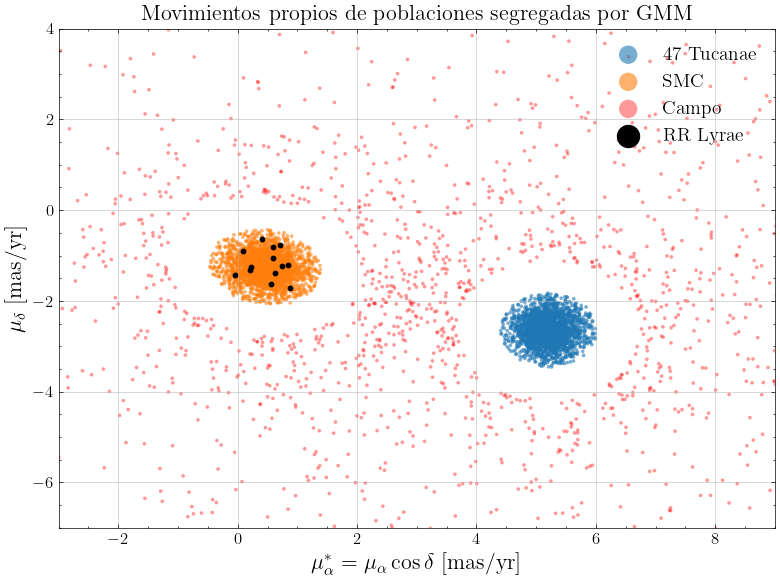

In [11]:
tabla_rrl = Table.read('fits/rubin_gaia_rrl.fits', format='fits')

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(tabla_47tuc['pmra'], tabla_47tuc['pmdec'], s=7, alpha=0.6, color='#1f77b4', edgecolors='none', label='47 Tucanae')

ax.scatter(tabla_smc['pmra'], tabla_smc['pmdec'], s=7, alpha=0.6, color='#ff7f0e', edgecolors='none', label='SMC')

ax.scatter(tabla_cielo['pmra'], tabla_cielo['pmdec'], s=7, alpha=0.4, color='red', edgecolors='none', label='Campo')

ax.scatter(tabla_rrl['pmra_1'],tabla_rrl['pmdec_1'], s=10, color='black', label='RR Lyrae')


ax.set_xlim(-3,9)
ax.set_ylim(-7, 4)
ax.set_xlabel(r"$\mu_{\alpha}^* = \mu_{\alpha} \cos \delta$ [mas/yr]", fontsize=16)
ax.set_ylabel(r"$\mu_{\delta}$ [mas/yr]", fontsize=16)
ax.set_title("Movimientos propios de poblaciones segregadas por GMM", fontsize=16)

ax.legend(loc='upper right', markerscale=5, fontsize=14)
ax.grid(True, alpha=0.7)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('image/6 - gmm proper motion.pdf')
plt.show()

# CMD de poblaciones segregadas

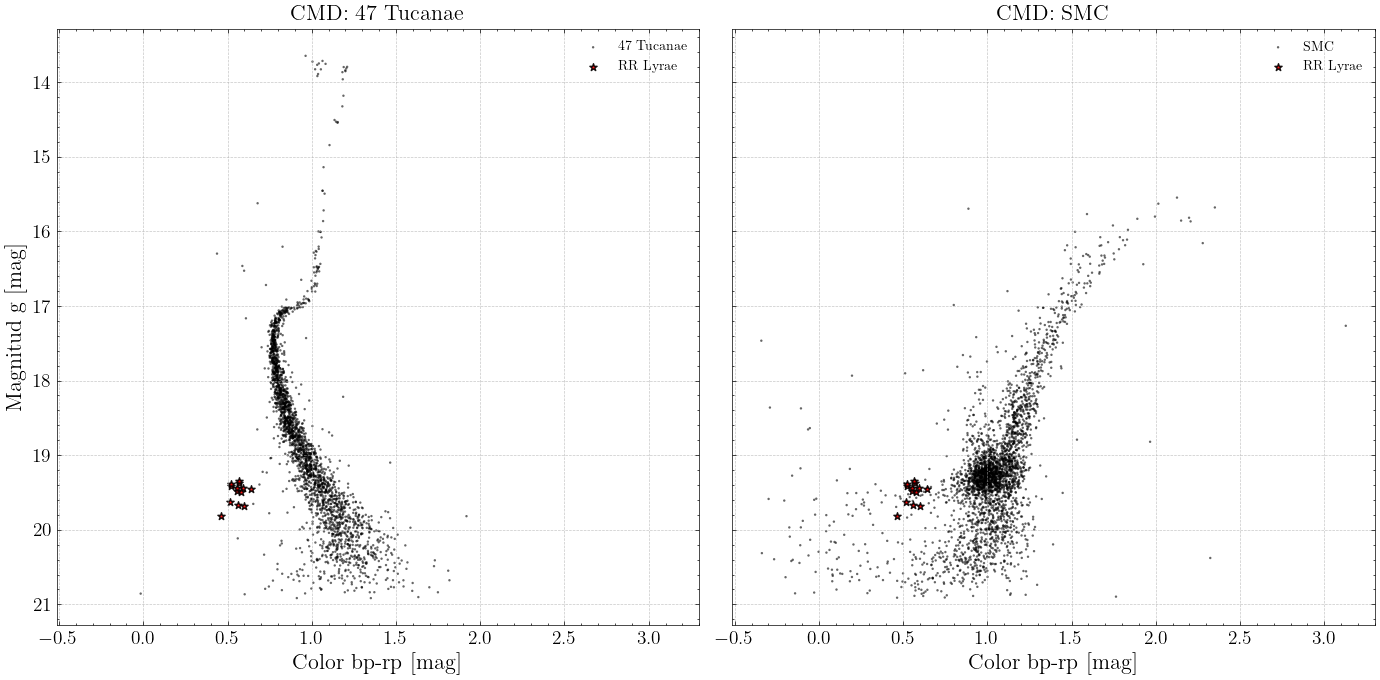

In [12]:
mag_rrl = tabla_rrl['g']
color_rrl = tabla_rrl['bp'] - tabla_rrl['rp']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True, sharex=True)

# 47 tuc
color_47 = tabla_47tuc['bp_rp']
mag_47 = tabla_47tuc['phot_g_mean_mag']

ax1.scatter(color_47, mag_47, s=3, alpha=0.6, color='black', edgecolors='none', label='47 Tucanae')
ax1.scatter(color_rrl, mag_rrl, s=30, alpha=0.9, color='red', marker='*', edgecolor='black', label='RR Lyrae')

ax1.set_xlabel(r"Color bp-rp [mag]", fontsize=16)
ax1.set_ylabel(r"Magnitud g [mag]", fontsize=16)
ax1.set_title("CMD: 47 Tucanae", fontsize=16)
ax1.tick_params(labelsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle="--", alpha=0.7)

# smc
color_smc = tabla_smc['bp_rp']
mag_smc = tabla_smc['phot_g_mean_mag']

ax2.scatter(color_smc, mag_smc, s=3, alpha=0.6, color='black', edgecolors='none', label='SMC')
ax2.scatter(color_rrl, mag_rrl, s=30, alpha=0.9, color='red', marker='*', edgecolor='black', label='RR Lyrae')

ax2.set_xlabel(r"Color bp-rp [mag]", fontsize=16)
ax2.set_title("CMD: SMC", fontsize=16)
ax2.tick_params(labelsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle="--", alpha=0.7)


ax1.invert_yaxis()
plt.tight_layout()
plt.savefig('image/6 - segregated cmd.pdf')
plt.show()

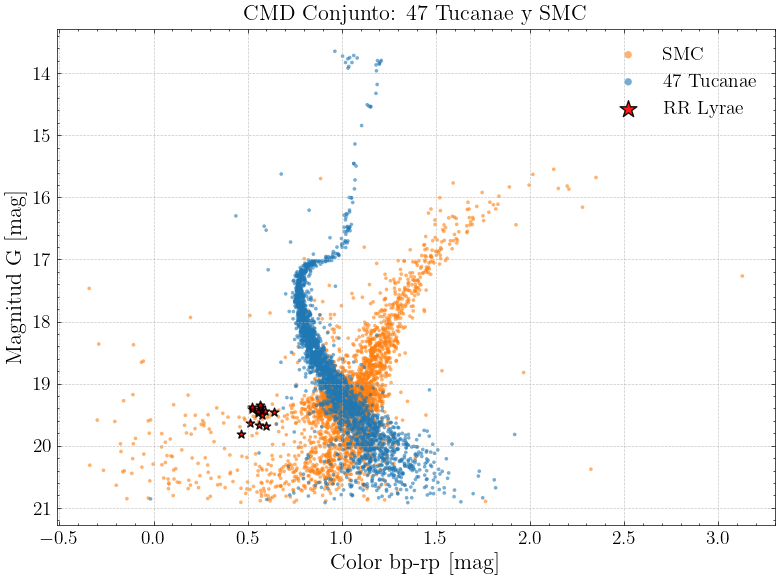

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
 
color_47 = tabla_47tuc['bp_rp']
mag_47 = tabla_47tuc['phot_g_mean_mag']

color_smc = tabla_smc['bp_rp']
mag_smc = tabla_smc['phot_g_mean_mag']

ax.scatter(color_smc, mag_smc, s=7, alpha=0.6, color='#ff7f0e', edgecolors='none', label='SMC')
ax.scatter(color_47, mag_47, s=7, alpha=0.6, color='#1f77b4', edgecolors='none', label='47 Tucanae')
ax.scatter(color_rrl, mag_rrl, s=40, alpha=0.9, color='red', marker='*', edgecolor='black', label='RR Lyrae')

ax.set_xlabel(r"Color bp-rp [mag]", fontsize=16)
ax.set_ylabel(r"Magnitud G [mag]", fontsize=16)
ax.set_title("CMD Conjunto: 47 Tucanae y SMC", fontsize=16)

ax.tick_params(labelsize=14)
ax.legend(loc='upper right', fontsize=14, markerscale=2)
ax.grid(True, linestyle="--", alpha=0.7)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('image/6 - combined_cmd.pdf')
plt.show()

# Isochrone Fitting

In [14]:
tabla_iso = Table.read('fits/isochrones.csv', format='csv', header_start=6, delimiter=' ')

mask_47 = (color_47 > 0.4) & (color_47 < 1.4) & (mag_47 > 14) & (mag_47 < 21)
color_47_m = color_47[mask_47]
mag_47_m = mag_47[mask_47]

mus = np.arange(11.5, 15.0, 0.02)
chi2_vals = []

for mu in mus:
    mag_iso_shifted = tabla_iso['G'] + mu
    color_iso = tabla_iso['BPft'] - tabla_iso['RP']
    
    mask_iso = (color_iso > 0.4) & (color_iso < 1.4) & (mag_iso_shifted > 14) & (mag_iso_shifted < 21)
    color_iso_m = color_iso[mask_iso]
    mag_iso_m = mag_iso_shifted[mask_iso]
    
    dists = []
    for c, m in zip(color_47_m, mag_47_m):
        d2 = (color_iso_m - c)**2 + (mag_iso_m - m)**2
        dists.append(np.min(d2))
    
    chi2_vals.append(np.sum(dists))

chi2_vals = np.array(chi2_vals)
mu_best = mus[np.argmin(chi2_vals)]

print(rf'mu best = {mu_best}')

mu best = 13.559999999999956


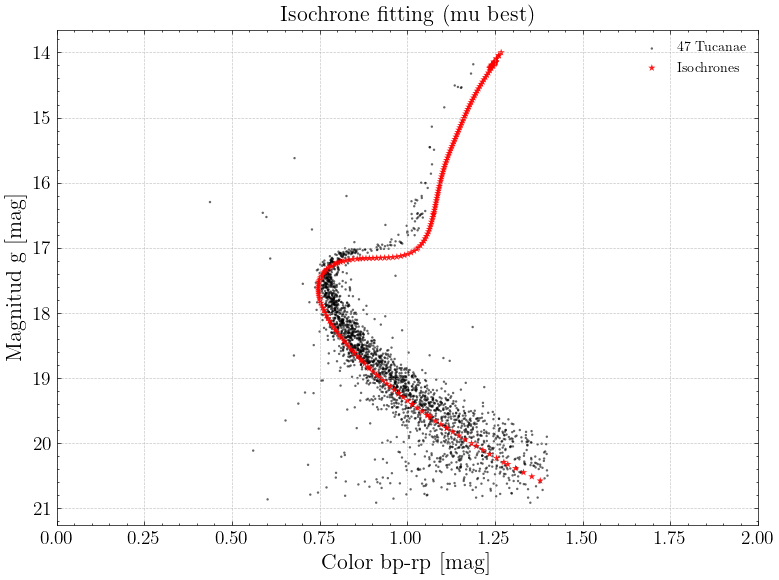

In [15]:
color_iso = tabla_iso['BPft']-tabla_iso['RP']
mag_iso = tabla_iso['G'] + mu_best
mask_iso = (color_iso > 0.4) & (color_iso < 1.4) & (mag_iso > 14) & (mag_iso < 21)

fig, ax = plt.subplots(figsize=(8, 6))

# 47 tuc
color_47 = tabla_47tuc['bp_rp']
mag_47 = tabla_47tuc['phot_g_mean_mag']
mask_47 = (color_47 > 0.4) & (color_47 < 1.4) & (mag_47 > 14) & (mag_47 < 21)
color_47_m = color_47[mask_47]
mag_47_m = mag_47[mask_47]

ax.scatter(color_47_m, mag_47_m, s=3, alpha=0.6, color='black', edgecolors='none', label='47 Tucanae')
ax.scatter(color_iso[mask_iso], mag_iso[mask_iso], s=30, alpha=0.9, color='red', marker='*', edgecolor='none', label='Isochrones')

ax.set_xlabel(r"Color bp-rp [mag]", fontsize=16)
ax.set_ylabel(r"Magnitud g [mag]", fontsize=16)
ax.set_title("Isochrone fitting (mu best)", fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(loc='upper right')
ax.grid(True, linestyle="--", alpha=0.7)
ax.set_xlim(0, 2)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('image/7 - Isochrone Fitting.pdf')
plt.show()

mu_best = 13.560
sigma_mu = 0.110
d = 5152.3 +- 261.0 pc


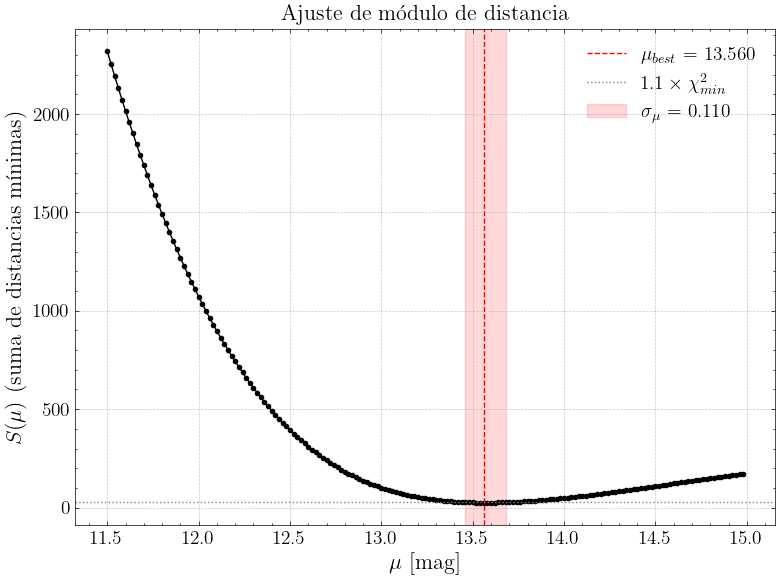

mu = 13.560 +0.120 / -0.100


In [16]:
chi2_min = chi2_vals.min()
threshold = 1.1 * chi2_min

mask_within = chi2_vals <= threshold
mu_range = mus[mask_within]

sigma_mu = (mu_range.max() - mu_range.min()) / 2

print(f"mu_best = {mu_best:.3f}")
print(f"sigma_mu = {sigma_mu:.3f}")

# propagación a distancia
d_best = 10**((mu_best + 5) / 5)
sigma_d = d_best * np.log(10) / 5 * sigma_mu
print(f"d = {d_best:.1f} +- {sigma_d:.1f} pc")

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(mus, chi2_vals, color='black', marker='o', markersize=3, linewidth=1)
ax.axvline(mu_best, color='red', linestyle='--', label=f'$\\mu_{{best}}$ = {mu_best:.3f}')
ax.axhline(threshold, color='gray', linestyle=':', label=f'$1.1\\times\\chi^2_{{min}}$')
ax.axvspan(mu_range.min(), mu_range.max(), color='red', alpha=0.15, label=f'$\\sigma_\\mu$ = {sigma_mu:.3f}')

ax.set_xlabel(r"$\mu$ [mag]", fontsize=16)
ax.set_ylabel(r"$S(\mu)$ (suma de distancias mínimas)", fontsize=16)
ax.set_title("Ajuste de módulo de distancia", fontsize=16)
ax.legend(fontsize=14)
ax.grid(True, linestyle="--", alpha=0.7)
ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('image/7 - Ajuste de distancia.pdf')
plt.show()

sigma_mu_plus = mu_range.max() - mu_best
sigma_mu_minus = mu_best - mu_range.min()
print(f"mu = {mu_best:.3f} +{sigma_mu_plus:.3f} / -{sigma_mu_minus:.3f}")

In [17]:
d_lit = 4450      
sigma_d_lit = 10   

error_pct = (d_best - d_lit) / d_lit * 100
print(f"d_best = {d_best:.1f} pc")
print(f"Error porcentual respecto a literatura: {error_pct:.2f}%")

d_plus = 10**((mu_best + sigma_mu_plus + 5)/5)
d_minus = 10**((mu_best - sigma_mu_minus + 5)/5)
print(f"d = {d_best:.0f} (+{d_plus-d_best:.0f} / -{d_best-d_minus:.0f}) pc")

d_best = 5152.3 pc
Error porcentual respecto a literatura: 15.78%
d = 5152 (+293 / -232) pc


# Distancias de las estrellas RR Lyrae

In [18]:
period = tabla_rrl['period'] 
FeH = tabla_rrl['Fe_H']

G_obs = tabla_rrl['g']
BP_obs = tabla_rrl['bp']
RP_obs = tabla_rrl['rp']

logP = np.log10(period)

# Magnitudes absolutas (Prudil et al. 2024)
mag_G  = -0.950 * logP + 0.202 * FeH + 0.614
mag_BP = -0.593 * logP + 0.228 * FeH + 0.913
mag_RP = -1.464 * logP + 0.167 * FeH + 0.113

# Módulos distancia
mu_G  = G_obs  - mag_G
mu_BP = BP_obs - mag_BP
mu_RP = RP_obs - mag_RP

# Distancias individuales
d_G  = 10**((mu_G  + 5) / 5)
d_BP = 10**((mu_BP + 5) / 5)
d_RP = 10**((mu_RP + 5) / 5)

print(rf'd_G = {np.mean(d_G)}')
print(d_G)
print(rf'd_BP = {np.mean(d_BP)}')
print(d_BP)
print(rf'd_RP = {np.mean(d_RP)}')
print(d_RP)

d_G = 65951.25633389632
        g        
-----------------
66246.07905545004
62267.18054904209
62893.57710468972
67708.03425642657
70650.02038962166
64505.37008650656
70203.79262091852
65133.29897158658
61619.03126131553
64390.55311366643
70799.66931674408
63697.23412842928
67252.49148625498
d_BP = 66684.6958037483
        bp        
------------------
 68183.84228775329
 62566.40055151069
63413.769436199385
 67788.09829516542
 72089.53447780682
65121.831305207445
 68549.12139339834
 67445.62446184698
 61382.51361910112
 63111.66362555998
 70904.55903597579
 66929.31085891806
 69414.77610028439
d_RP = 64206.63105398692
        rp        
------------------
 64300.39557438518
 60694.17034425738
63063.873606387046
  65963.1092420446
 68019.35272743835
 62108.31886922326
 68788.97308674132
 65025.62281074743
  59790.3167920191
62285.006913769925
 65943.91808127036
  63140.0319874409
  65563.1136661052


In [22]:
print(rf'mag_G = {np.mean(mag_G)}')
print(mag_G)
print(rf'mag_BP = {np.mean(mag_BP)}')
print(mag_BP)
print(rf'mag_RP = {np.mean(mag_RP)}')
print(mag_RP)

mag_G = 0.41490250059806566
       period      
-------------------
 0.3402321073312058
  0.503421993194394
0.41808251922985196
0.28961097369338684
 0.2518545423892972
0.32179264373401806
 0.5858351266839501
 0.2802566222670061
0.43403966845730174
  0.582669221551224
 0.4295118538003573
0.43010012630125705
 0.5263251091416037
mag_BP = 0.5787093468285579
       period      
-------------------
 0.4995666455333282
 0.6727681464470635
 0.5960591537398681
0.46083474736534874
 0.4056748947412161
 0.4819419752868881
 0.7486695363522233
  0.448881099768686
 0.5937906557222409
 0.7517888582864829
 0.5787351978144537
 0.6096752335444249
 0.6748353641690273
mag_RP = 0.10353412001588004
        period       
---------------------
  0.03452577649520101
  0.18500510384159913
  0.08667978432085068
-0.033383591960484724
-0.046837474337582605
 0.014767129790662595
  0.27737786924352686
 -0.03914160264601112
  0.12858572757550618
   0.2652844150395462
  0.13892326332831617
  0.09654201212670939
  0.237

In [23]:
print('Period')
print(period)

print('FeH')
print(FeH)

Period
      period      
------------------
0.6054991409653755
0.5743502978656999
0.6311064371409005
0.6614769962462074
0.6227913232736288
0.6148449647348755
0.5290025136479025
0.6570577755280694
0.5725188673459494
 0.546288242824125
 0.545808276355335
0.6312630502256031
0.5123332005585699
FeH
 Fe_H
-----
-2.38
-1.68
-1.91
-2.45
-2.76
-2.44
-1.44
-2.51
-2.03
-1.39
-2.15
-1.85
 -1.8


# Lightcurves

In [19]:
lightcurve_dir = "C:/Users/nicol/Downloads/todas_las_curvas/"
archivos = glob.glob(os.path.join(lightcurve_dir, "*.csv"))
print(f"Total de archivos encontrados: {len(archivos)}")

lightcurves = {}
for f in archivos:
    df = pd.read_csv(f)
    if df.empty:
        continue
    sid = df['source_id'].iloc[0]
    lightcurves[sid] = df

print(f"Curvas de luz cargadas: {len(lightcurves)}")

Total de archivos encontrados: 238
Curvas de luz cargadas: 238


In [20]:
df_rrl = tabla_rrl['source_id_1', 'period', 'best_classification'].to_pandas()
df_rrl['n_epochs'] = df_rrl['source_id_1'].apply(count_good_points)

cinco_rrl = df_rrl.sort_values('n_epochs', ascending=False).head(5).reset_index(drop=True)

assert cinco_rrl['source_id_1'].isin(lightcurves.keys()).all(), "Alguna de las 5 no tiene lightcurve cargada"
print(cinco_rrl[['source_id_1', 'period', 'n_epochs']])

for _, row in cinco_rrl.iterrows():
    sid = row['source_id_1']
    P = row['period']
    
    if sid not in lightcurves:
        print(f"⚠ source_id_1 {sid} no encontrado en lightcurves/")
        continue
    
    df = lightcurves[sid]

           source_id_1    period  n_epochs
0  4689819689815344896  0.631106        47
1  4689804434093910016  0.631263        46
2  4689654415184327680  0.605499        45
3  4689845833283317504  0.614845        44
4  4689879162227668736  0.622791        44


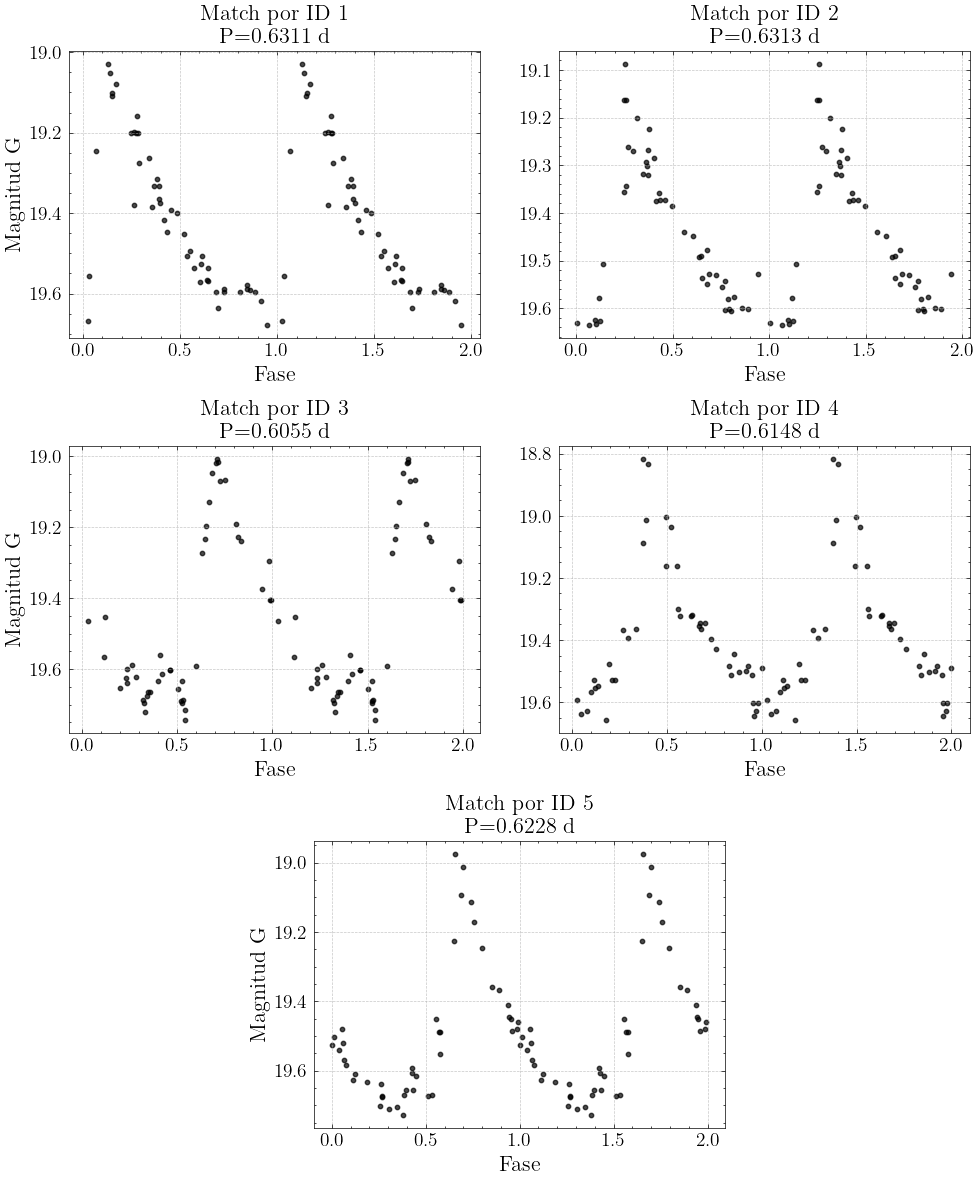

In [21]:
fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(3, 4, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[1, 0:2]),
    fig.add_subplot(gs[1, 2:4]),
    fig.add_subplot(gs[2, 1:3]),
]

nid = 0
for ax, (_, row) in zip(axes, cinco_rrl.iterrows()):
    sid, P = row['source_id_1'], row['period']
    df = lightcurves.get(sid)
    time, mag = get_clean_band(df, band='g')

    phase = (time % P) / P
    phase_ext = np.concatenate([phase, phase + 1])
    mag_ext = np.concatenate([mag, mag])

    ax.scatter(phase_ext, mag_ext, s=10, color='black', alpha=0.7)
    ax.invert_yaxis()
    ax.set_title(f"Match por ID {nid+1}\nP={P:.4f} d", fontsize=16)
    ax.set_xlabel("Fase", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.tick_params(labelsize=14)
    nid+=1

axes[0].set_ylabel('Magnitud G', fontsize=16)
axes[2].set_ylabel('Magnitud G', fontsize=16)
axes[4].set_ylabel('Magnitud G', fontsize=16)

plt.tight_layout()
plt.savefig('image/9 - Lightcurves.pdf')
plt.show()